# 02 Validation Iwabuchi

- see: Iwabuchi, H., & Suzuki, T. (2009). Fast and accurate radiance
  calculations using truncation approximation for anisotropic
  scattering phase functions. Journal of Quantitative Spectroscopy
  and Radiative Transfer, 110(17), 1926-1939.

In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.integrate import simpson, trapezoid

from pytrunc.constant import DIR_ROOT
from pytrunc.phase import calc_moments
from pytrunc.truncation import delta_m_phase_approx, gt_phase_approx
from pytrunc.utils import integrate_lobatto

save_fig = False

## Truncation approximation for the anisotropic phase function

### Get realistic water cloud phase function from mie calculation

Text(0, 0.5, 'Phase function []')

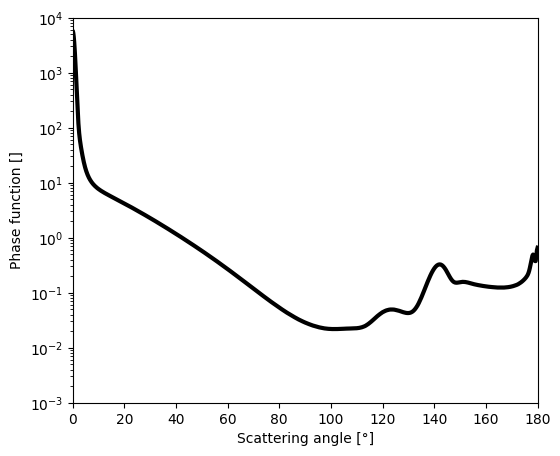

In [2]:
# in the paper (Iwabuchi et al. 2009) water cloud at wl = 500 nm and
# reff = 8 um

# wc available in smartg auxdata: https://github.com/hygeos/smartg
# Follow smartg README to download auxdata, then create the environment
# variable 'SMARTG_DIR_AUXDATA' where auxdata have been downloaded
# import os
# from pathlib import Path
# wc_path = Path(os.environ['SMARTG_DIR_AUXDATA']) / 'clouds/wc_sol.nc'
# ds = xr.open_dataset(wc_path)
# pha_exact = ds['phase'].interp(reff=8, wav=500,
#                                method='linear').values[0, :]

# wc at the correct wavelength and effective radius available in
# pytrunc/data
ds = xr.open_dataset(DIR_ROOT / 'pytrunc' / 'data' / 'wc_wl500_reff8.nc')

theta = ds['theta'].values
pha_exact = ds["phase"].values[0,:]

method = 'lobatto'
# method = 'trapezoid'
# method = 'simpson' # use pair number for theta

INTEGRATORS = {
    "simpson": simpson,
    "trapezoid": trapezoid,
    "lobatto": integrate_lobatto
    }
integrate_m = INTEGRATORS[method]

# theta = np.linspace(0., 180., 18000)
# pha_exact = np.interp(theta, ds.theta.values, pha_exact)

# theta, _ = quadrature_lobatto(0., 180., 7201)
# pha_exact = np.interp(theta, ds.theta.values, pha_exact)

mu = np.cos(np.deg2rad(theta))
idmu = np.argsort(mu)
# renormalize depending on the chosen integration method
if method == 'lobatto':
    sin_th = np.sin(np.deg2rad(theta))
    pha_exact = (2. * pha_exact) / integrate_m(pha_exact*sin_th,
                                               np.deg2rad(theta))
else:
    pha_exact = (2. * pha_exact) / integrate_m(pha_exact[idmu], mu[idmu])

plt.figure(figsize=(6,5))
plt.plot(theta, pha_exact, c='k', lw=3)
plt.yscale('log')
plt.ylim(ymin=1e-3, ymax=1e4)
plt.xlim(xmin=0, xmax=180)
plt.xlabel('Scattering angle [°]')
plt.ylabel('Phase function []')

### Plot exact and approximated phase functions
 - Reproduce Fig.1a

integral(P_exact)= 2.0
integral(P_approx_dm)= 2.0000675723515875
f = 0.43294807007378455


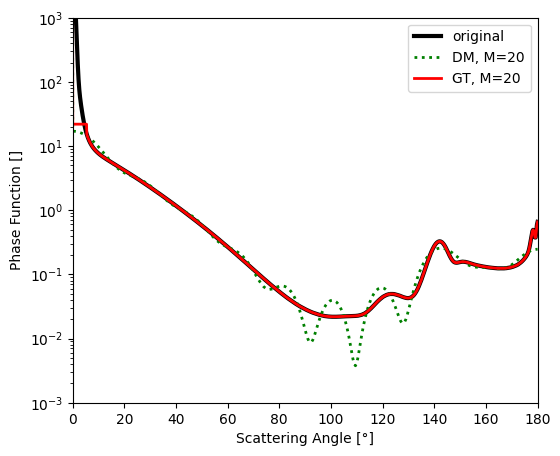

In [3]:
m_max = 20
ds_dm = delta_m_phase_approx(pha_exact, theta, m_max, method=method)
f = float(ds_dm['f'].values)
ds_gt = gt_phase_approx(pha_exact, theta, f, method=method, th_tol=12)

plt.figure(figsize=(6,5))
plt.plot(theta, pha_exact, 'k', lw=3, label='original')
plt.plot(theta, ds_dm['phase_approx'], 'g:', lw=2, label=f'DM, M={m_max}')
plt.plot(theta, ds_gt['phase_approx'], 'r', lw=2, label=f'GT, M={m_max}')
plt.yscale('log')
plt.ylim(ymin=1e-3, ymax=1e3)
plt.xlim(xmin=0, xmax=180)
plt.legend()
plt.ylabel("Phase Function []")
plt.xlabel("Scattering Angle [°]")
if save_fig:
    plt.savefig("iwabuchi_fig1a.png", dpi=200)

mu = np.cos(np.deg2rad(theta))
idmu = np.argsort(mu)
pha_approx_dm = ds_dm['phase_approx'].values
if method == 'lobatto':
    th_rad = np.deg2rad(theta)
    print("integral(P_exact)=",
          integrate_m(pha_exact*np.sin(th_rad), th_rad))
    print("integral(P_approx_dm)=",
          integrate_m(pha_approx_dm*np.sin(th_rad), th_rad))
else:
    print("integral(P_exact)=", integrate_m(pha_exact[idmu], mu[idmu]))
    print("integral(P_approx_dm)=",
          integrate_m(pha_approx_dm[idmu], mu[idmu]))
print("f =",f)

### Zoom of previous plot
- Fig.1b

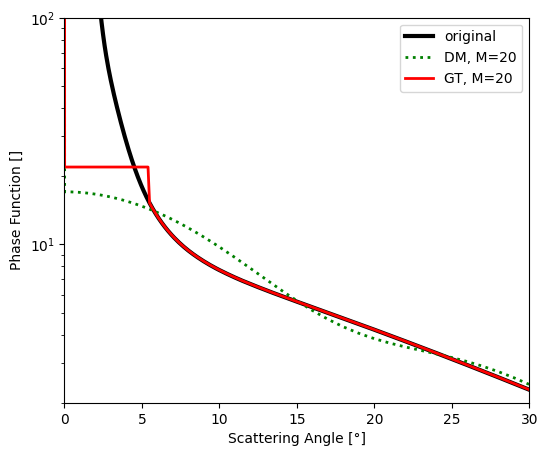

In [4]:
plt.figure(figsize=(6,5))
plt.plot(theta, pha_exact, 'k', lw=3, label='original')
plt.plot(theta, ds_dm['phase_approx'], 'g:', lw=2, label=f'DM, M={m_max}')
plt.plot(theta, ds_gt['phase_approx'], 'r', lw=2, label=f'GT, M={m_max}')
plt.yscale('log')
plt.ylim(ymin=2, ymax=100)
plt.xlim(xmin=0, xmax=30)
plt.legend()
plt.ylabel("Phase Function []")
plt.xlabel("Scattering Angle [°]")
if save_fig:
    plt.savefig("iwabuchi_fig1b.png", dpi=200)

### Plot exact and approximated phase moments
- Fig.2a

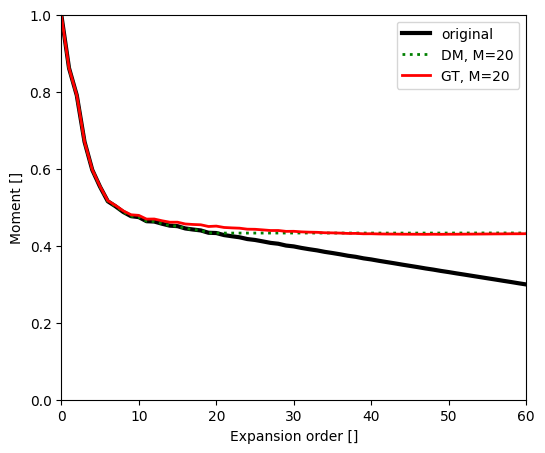

In [5]:
n_expan = 60
chi_exact = calc_moments(phase=pha_exact, theta=theta, m_max=n_expan,
                         method=method, normalize=True)
chi_approx_dm = calc_moments(phase=ds_dm['phase_approx'].values, theta=theta,
                             m_max=n_expan, method=method, normalize=True)
chi_approx_gt = calc_moments(phase=ds_gt['phase_approx'].values, theta=theta,
                             m_max=n_expan, method=method, normalize=True)

exp_order = np.arange(61)
plt.figure(figsize=(6,5))
plt.plot(chi_exact, 'k', lw=3, label='original')
plt.plot(chi_approx_dm, 'g:', lw=2, label=f'DM, M={m_max}')
plt.plot(chi_approx_gt, 'r', lw=2, label=f'GT, M={m_max}')
plt.xlim(xmin=0, xmax = 60)
plt.ylim(ymin=0, ymax=1)
plt.legend()
plt.ylabel("Moment []")
plt.xlabel("Expansion order []")
if save_fig:
    plt.savefig("iwabuchi_fig2a.png", dpi=200)

### Plot moment ratio
- Fig.2b

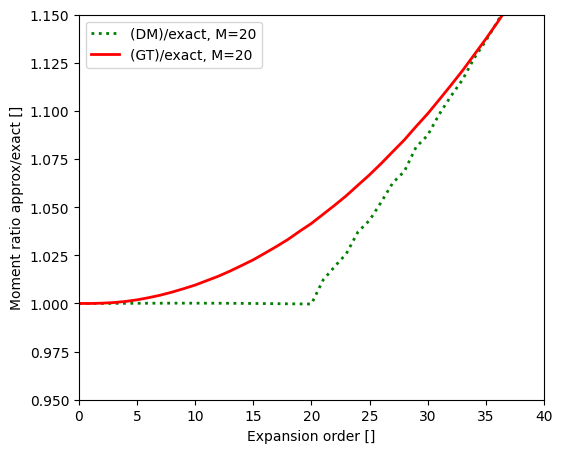

In [6]:
exp_order = np.arange(61)
plt.figure(figsize=(6,5))
plt.plot(chi_approx_dm/chi_exact, 'g:', lw=2, label=f'(DM)/exact, M={m_max}')
plt.plot(chi_approx_gt/chi_exact, 'r', lw=2, label=f'(GT)/exact, M={m_max}')
plt.xlim(xmin=0, xmax = 40)
plt.ylim(ymin=0.95, ymax=1.15)
plt.legend()
plt.ylabel("Moment ratio approx/exact []")
plt.xlabel("Expansion order []")
if save_fig:
    plt.savefig("iwabuchi_fig2b.png", dpi=200)